In [14]:
import numpy as np 
import pandas as pd # numpy wrapper 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [15]:
# all the stocks that make up the snp500 index
tickers = ['AOS', 'ABT', 'ABBV', 'ABMD', 'ACN', 'ATVI', 'ADM', 'ADBE', 'ADP', 'AAP', 'AES', 'AFL', 'A', 'AIG', 'APD', 'AKAM', 'ALK', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AMD', 'AEE', 'AAL', 'AEP',
              'AXP', 'AMT', 'AWK', 'AMP', 'ABC', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'ANTM', 'AON', 'APA', 'AAPL', 'AMAT', 'APTV', 'ANET', 'AIZ', 'T', 'ATO', 'ADSK', 'AZO', 'AVB', 'AVY', 'BKR', 'BLL', 'BAC', 'BBWI', 'BAX', 'BDX', 'WRB', 'BRK-A', 
              'BBY', 'BIO', 'TECH', 'BIIB', 'BLK', 'BK', 'BA', 'BKNG', 'BWA', 'BXP', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'CHRW', 'CDNS', 'CZR', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CTLT', 'CAT', 'CBOE', 'CBRE', 'CDW', 'CE', 'CNC', 
              'CNP', 'CDAY', 'CERN', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CTXS', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CMA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 
              'GLW', 'CTVA', 'COST', 'CTRA', 'CCI', 'CSX', 'CMI', 'CVS', 'DHI', 'DHR', 'DRI', 'DVA', 'DE', 'DAL', 'XRAY', 'DVN', 'DXCM', 'FANG', 'DLR', 'DFS', 'DISCA', 'DISCK', 'DISH', 'DIS', 'DG', 'DLTR', 'D', 'DPZ', 'DOV', 'DOW', 'DTE', 'DUK', 
              'DRE', 'DD', 'DXC', 'EMN', 'ETN', 'EBAY', 'ECL', 'EIX', 'EW', 'EA', 'EMR', 'ENPH', 'ETR', 'EOG', 'EPAM', 'EFX', 'EQIX', 'EQR', 'ESS', 'EL', 'ETSY', 'RE', 'EVRG', 'ES', 'EXC', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FAST', 'FRT', 
              'FDX', 'FITB', 'FRC', 'FE', 'FIS', 'FISV', 'FLT', 'FMC', 'F', 'FTNT', 'FTV', 'FBHS', 'FOXA', 'FOX', 'BEN', 'FCX', 'AJG', 'GRMN', 'IT', 'GE', 'GNRC', 'GD', 'GIS', 'GPC', 'GILD', 'GL', 'GPN', 'GM', 'GS', 'GWW', 'HAL', 'HIG', 'HAS', 'HCA', 
              'PEAK', 'HSIC', 'HSY', 'HES', 'HPE', 'HLT', 'HOLX', 'HD', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUM', 'HII', 'HBAN', 'IEX', 'IDXX', 'ITW', 'ILMN', 'INCY', 'IR', 'INTC', 'ICE', 'IBM', 'IP', 'IPG', 'IFF', 'INTU', 'ISRG', 'IVZ', 'IPGP', 
              'IQV', 'IRM', 'JBHT', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'JNPR', 'K', 'KEY', 'KEYS', 'KMB', 'KIM', 'KMI', 'KLAC', 'KHC', 'KR', 'LHX', 'LH', 'LRCX', 'LW', 'LVS', 'LDOS', 'LEN', 'LLY', 'LNC', 'LIN', 'LYV', 'LKQ', 'LMT', 'L', 'LOW', 'LUMN',
              'LYB', 'MTB', 'MRO', 'MPC', 'MKTX', 'MAR', 'MMC', 'MLM', 'MAS', 'MA', 'MTCH', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'FB', 'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'MHK', 'MOH', 'TAP', 'MDLZ', 'MPWR', 'MMM', 'MNST', 'MCO', 
              'MS', 'MOS', 'MSI', 'MSCI', 'NDAQ', 'NTAP', 'NFLX', 'NWL', 'NEM', 'NWSA', 'NWS', 'NEE', 'NLSN', 'NKE', 'NI', 'NDSN', 'NSC', 'NTRS', 'NOC', 'NLOK', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY', 'ODFL', 'OMC', 'OKE', 'ORCL', 
              'OGN', 'OTIS', 'PCAR', 'PKG', 'PARA', 'PH', 'PAYX', 'PAYC', 'PYPL', 'PENN', 'PNR', 'PBCT', 'PEP', 'PKI', 'PFE', 'PM', 'PSX', 'PNW', 'PXD', 'PNC', 'POOL', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG', 'PTC', 'PSA', 'PHM', 'PVH', 
              'QRVO', 'PWR', 'QCOM', 'DGX', 'RL', 'RJF', 'RTX', 'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RHI', 'ROK', 'ROL', 'ROP', 'ROST', 'RCL', 'SPGI', 'CRM', 'SBAC', 'SLB', 'STX', 'SEE', 'SRE', 'NOW', 'SHW', 'SBNY', 'SPG', 'SWKS', 'SJM', 'SNA',
              'SEDG', 'SO', 'LUV', 'SWK', 'SBUX', 'STT', 'STE', 'SYK', 'SIVB', 'SYF', 'SNPS', 'SYY', 'TMUS', 'TROW', 'TTWO', 'TPR', 'TGT', 'TEL', 'TDY', 'TFX', 'TER', 'TSLA', 'TXN', 'TXT', 'TMO', 'TJX', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC', 'TWTR', 
              'TYL', 'TSN', 'USB', 'UDR', 'ULTA', 'UAA', 'UA', 'UNP', 'UAL', 'UNH', 'UPS', 'URI', 'UHS', 'VLO', 'VTR', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VFC', 'VTRS', 'V', 'VNO', 'VMC', 'WAB', 'WMT', 'WBA', 'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 
              'WRK', 'WY', 'WHR', 'WMB', 'WTW', 'WYNN', 'XEL', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZION', 'ZTS']

In [44]:
# stocks_histories = yf.download(tickers, period="5y", auto_adjust=True, group_by='ticker')
stocks_histories = yf.download(tickers, period="5y", auto_adjust=False)['Adj Close']
stocks_histories


[*********************100%***********************]  505 of 505 completed

33 Failed downloads:
['PKI', 'MRO', 'BLL', 'WRK', 'DFS', 'CTLT', 'CDAY', 'DISCA', 'FBHS', 'FLT', 'ABMD', 'TWTR', 'FRC', 'DRE', 'RE', 'PBCT', 'HES', 'ANSS', 'SIVB', 'WBA', 'JNPR', 'DISH', 'PXD', 'NLOK', 'CTXS', 'ANTM', 'DISCK', 'NLSN', 'ABC', 'PEAK', 'CERN', 'PARA', 'ATVI']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


Ticker,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,WYNN,XEL,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-11-16,106.586243,12.79,134.800140,117.106316,80.938416,NaN,NaN,103.853508,227.996994,460.950012,...,92.277283,63.817890,31.461344,45.052082,92.143669,95.461876,140.146240,345.980011,33.802551,158.025864
2020-11-17,106.189926,12.70,133.229553,116.220467,81.637871,NaN,NaN,103.296196,226.945190,467.950012,...,91.780548,62.041153,31.881824,44.344749,90.781258,94.805794,140.080994,340.790009,33.674999,158.159729
2020-11-18,102.410545,12.74,132.158737,114.896576,81.234650,NaN,NaN,100.290291,223.138275,459.470001,...,93.153893,60.221684,30.678112,44.353809,89.863480,94.924225,138.252396,337.579987,33.113747,156.314590
2020-11-19,105.049355,12.79,130.356201,115.490387,82.016380,NaN,NaN,101.414085,226.368134,466.410004,...,96.183052,59.239334,30.834764,44.317543,89.286377,95.926605,136.703735,358.390015,32.646042,159.001068
2020-11-20,107.185509,12.53,128.794540,114.224884,82.979126,NaN,NaN,101.313583,226.591522,462.920013,...,92.812996,59.205166,30.455509,44.798168,89.295837,95.671455,136.153259,354.989990,32.552502,158.895950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-10,146.360001,13.31,47.549999,269.429993,218.710007,NaN,NaN,125.889999,244.550003,328.850006,...,128.880005,80.400002,118.220001,11.000000,151.050003,148.259995,88.730003,260.630005,52.610001,119.790001
2025-11-11,149.419998,12.99,51.060001,275.250000,225.169998,NaN,NaN,127.000000,242.559998,333.220001,...,126.070000,81.160004,119.779999,10.980000,149.779999,150.750000,88.500000,255.169998,52.669998,120.120003
2025-11-12,151.520004,13.46,51.020000,273.470001,233.229996,NaN,NaN,128.820007,246.529999,337.049988,...,125.019997,80.720001,118.120003,10.840000,149.869995,149.369995,90.029999,255.690002,52.450001,121.250000


In [53]:
# 1) remove tickers that have no data at all
stocks_histories = stocks_histories.dropna(axis=1, how='all')

# 2) fill small gaps so we don't lose dates
stocks_histories = stocks_histories.fillna(method='ffill').fillna(method='bfill')

# 3) compute daily returns and drop the first NaN row
stocks_histories.pct_change().dropna()

# optional quick check
print("prices shape after cleanup:", stocks_histories.shape)


prices shape after cleanup: (1256, 472)


C:\Users\35387\AppData\Local\Temp\ipykernel_38440\454331437.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stocks_histories = stocks_histories.fillna(method='ffill').fillna(method='bfill')


In [ ]:
# calculate the daily returns 
daily_returns = stocks_histories.pct_change(fill_method=None).dorpna()

# calculate the anunual means
annual_means_returns = daily_returns.mean() * 252 # 252 trading days in a year

# calculate annual returns variance 
annual_returs_variance = daily_returns.var() * 252


In [58]:
# stocks = list(stocks_histories.columns)
tickers = annual_returs_variance.index.tolist() 
df2 = pd.DataFrame({'Stock Symbols': tickers})

# remove the date column - create columns for stock symbols and their variances 
# df2['Variances'] = annual_returs_variance.values
# df2['Returns'] = annual_means_returns.values

df2 = pd.DataFrame({
    'Stock Symbols': tickers,
    'Variances': annual_returs_variance.reindex(tickers).values,
    'Returns': annual_means_returns.reindex(tickers).values
})
# show the data 
df2



,Stock Symbols,Variances,Returns
0,A,0.080885,0.105476
1,AAL,0.237210,0.118844
2,AAP,0.257490,-0.073022
3,AAPL,0.079052,0.211195
4,ABBV,0.050164,0.239072
...,...,...,...
467,YUM,0.040405,0.109689
468,ZBH,0.067339,-0.054548
469,ZBRA,0.152845,0.005952
470,ZION,0.189851,0.178276


Returns      0
Variances    0
dtype: int64
means: [3.76346788e-17 2.29571541e-16]
stds:  [1. 1.]


c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

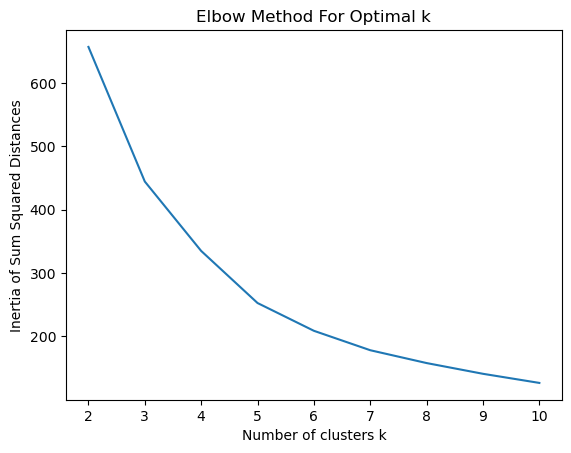

In [ ]:
# using the elbow method to find the optimal number of clusters

# get and store the annual returns and annualvariances
X = df2[['Returns', 'Variances']].values

# https://datadave1.medium.com/k-means-clustering-to-diversify-your-stock-portfolio-50d807e90835
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# checking for NaN values
print(df2[['Returns','Variances']].isna().sum())     # should be 0 for both
print("means:", Xs.mean(axis=0))
print("stds: ", Xs.std(axis=0, ddof=0))

# inertia is the within cluster sum of squared distances from each sample to its nearest cluster center
inertia = []
for k in range(2,11):
    # create and train the kmeans model 
    kmeans = KMeans(n_clusters=k, n_init=50, random_state=42)

    # train the model on the data 
    kmeans.fit(Xs)
    # append the inertia to the list - sum of squared distances to nearest cluster center
    inertia.append(kmeans.inertia_)

# plot the elbow graph 
plt.plot(range(2,11), inertia)
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia of Sum Squared Distances')
plt.show()